# Analysis of Degree Modifiers in Wiki talk-pages
## Outline:
- Start with some list of modifiers of degree
- open wiki talk pages and see if there are other hedges by asking gemini
- create final list of modifiers of degree by adding the found set
- extract all modifiers of degree based on string matching
- use gemini to filter out cases where modifiers of degree appear 
- add labels of the context in which the modifier is used including the following:
    - whether it's in a question
    - valence 
    - whether the modifier fuctions to soften the utterance, be formal, or be literal


Load libraries etc

In [78]:
import os
from google import genai
from dotenv import load_dotenv
import json
import pandas as pd
import xml.etree.ElementTree as ET
from google.genai import types
load_dotenv()
client = genai.Client(
    api_key=os.getenv("google_api_key"),
)
MAX_ENTRIES = 1000

Functions

In [79]:
import json, re

def parse_model_json(response):
    """Robust parser: strips backtick fences and quotes bare keys before parsing."""
    text = response.strip()
    text = re.sub(r'^`+\s*(?:json)?\s*', '', text)
    text = re.sub(r'\s*`+\s*$', '', text)
    text = text.strip()
    text = re.sub(r'([{,]\s*)([A-Za-z_][A-Za-z0-9_]*)\s*:', r'\1"\2":', text)
    try:
        return json.loads(text)
    except json.JSONDecodeError:
        return None


def extract_key_value(response_text, key):
    """Extract a single field (e.g. "category") from the model's JSON response text."""
    parsed = parse_model_json(response_text)
    if parsed is None:
        return None
    return parsed.get(key)


def get_index_output(row, key):
    """
    Given one line from a downloaded batch result JSONL file, return
    (index, value): index is the original DataFrame row index (from the
    request's "key" field), value is the requested field extracted from
    the model's JSON response.
    """
    result = json.loads(row) if isinstance(row, str) else row

    request_key = result.get("key")
    index = int(request_key) if request_key is not None else None

    if not result.get("response"):
        print(f"Error for key {request_key}: {result.get('error')}")
        return index, None

    try:
        response_text = result["response"]["candidates"][0]["content"]["parts"][0]["text"]
    except (KeyError, IndexError):
        return index, None

    return index, extract_key_value(response_text, key)
def create_inline_requests(replacement_tuples, prompt_text,key):
    for replace_tuple in replacement_tuples:
        prompt_text = prompt_text.replace(replace_tuple[0], replace_tuple[1])
    return { "key": key, "request": {"contents": [{"parts": [{"text": prompt_text}], "role": "user"}]},}

def create_batch_job(inline_requests, display_name, model="gemini-3-flash-preview"):
    batch_input_path = f"{display_name}_input.jsonl"
    with open(batch_input_path, "w", encoding="utf-8") as f:
        for req in inline_requests:
            f.write(json.dumps(req, ensure_ascii=False) + "\n")

    uploaded_file = client.files.upload(
        file=batch_input_path,
        config=types.UploadFileConfig(display_name=display_name, mime_type="jsonl"),
    )

    batch_job = client.batches.create(
        model=model,
        src=uploaded_file.name,
        config={'display_name': display_name},
    )
    return batch_job

### Decide on list of hedges

In [ ]:
# starting list of hedges
JP_DEGREE_MODIFIERS = [
    "ちょっと", "少し", "やや", "かなり", "非常に", "大変", "とても", "すごく", "めっちゃ", 
    "かなりの", "相当な", "極めて", "非常に多くの", "大いに", "大いなる", "大きな", 
    "大きく", "大きめの", "大きめに", "大きめな", "大きめで", "大きめだと"
]
EN_DEGREE_MODIFIERS = [
    "a bit", "a little", "somewhat", "fairly", "quite", "very", "extremely", "highly", "greatly", 
    "considerably", "substantially", "significantly", "markedly", "notably", "exceptionally", "remarkably", "tremendously", "immensely", "hugely", "enormously", "massively", "overwhelmingly", "profoundly", "exceedingly", "extraordinarily", "unusually", "abundantly", "plentifully", "copiously", "awfully", "terribly", "horribly", "dreadfully", "atrociously", "appallingly", "shockingly", "staggeringly", "stunningly", "breathtakingly", "mind-blowingly", "jaw-droppingly", "eye-poppingly", "heart-stoppingly", "spine-tinglingly", "hair-raisingly", "blood-curdlingly", "bone-chillingly"
]

Prompt wordings

In [80]:
# prompt for additional hedging extraction

find_other_modifier_prompt = """You are analyzing English text to find degree modifiers that are NOT already in a known list.

DEFINITION: A degree modifier is a word or short phrase that scales the intensity of a gradable adjective, adverb, or verb — it answers "to what extent / how much" (e.g., "very good," "barely visible," "completely wrong," "kind of slow"). Do NOT count:
- frequency/habituality adverbs (often, rarely, usually, typically, generally, mostly)
- epistemic/evidential adverbs marking certainty or source of a claim (probably, apparently, obviously, allegedly, supposedly, arguably, definitely, presumably, possibly)
- evaluative stance adverbs commenting on the whole proposition (surprisingly, worryingly, unfortunately, ideally)
- plain manner adverbs (quickly, carefully) unless they are clearly functioning to scale intensity rather than describe how an action was performed

TASK:
1. Read the text below.
2. Identify every word or short phrase functioning as a degree modifier.
3. Exclude any modifier that appears (in any form/case) in the EXCLUSION LIST below.
4. For each remaining (new) modifier found, report: the modifier itself, the word/phrase it modifies, and the exact quote/sentence it appears in.
5. If a modifier is ambiguous (could be degree or something else depending on context), include it but note the ambiguity.
6. If no new modifiers are found, return an empty array — do not force matches.

EXCLUSION LIST (already known — do not report these):
Overly, Excessively, Truly, Barely, Hardly, Scarcely, Just, Merely, Only, A tad, A touch, Marginally, Minimally, Nominally, Mildly, Vaguely, Kind of, Rather, Entirely, Somewhat, Considerably, Substantially, Significantly, Notably, Remarkably, Noticeably, Appreciably, Highly, Incredibly, Extremely, Unbelievably, Very, Exceptionally, Extraordinarily, Unusually, Immensely, Tremendously, Enormously, Hugely, Greatly, Vastly, Completely, Absolutely, Utterly, Totally, Wholly, Fully, Thoroughly, Perfectly, Supremely, Infinitely, Profoundly, Intensely, Strongly, Comparatively, Relatively, Proportionally, Mega, Ultra, So, Real, Way, Way too, Dead, Well, Mad, Hella, Wicked, Bloody, Damn, Freaking, Crazy, Crazily, Measurably, Quantifiably, Reasonably, Moderately, A little, A little bit, A bit, Slightly, Sort of, Kinda, Sorta, A whisker, A smidge, A smidgen, A hair, Faintly, Literally, Positively, Downright, Plain, Monumentally, Staggeringly, Astonishingly, Astoundingly, Phenomenally, Spectacularly, Stunningly, Breathtakingly, Achingly, Quite, Almost, Nearly, Practically, Virtually, Essentially, Basically, Just about, All but, Lil', Awfully, Terribly, Frightfully, Painfully, Deathly, Blindingly, Insanely, Ridiculously, Stupidly, Sick, Proper, Jolly, Fricking, Effing, Goddamn, Seriously, Stupid

TEXT TO ANALYZE:

{text}


OUTPUT FORMAT: Return strict JSON only — a single array containing ONE object per modifier found. If the text contains multiple new modifiers, include all of them as separate objects in the same array; do not merge them or return only one. Example shape with two entries:
[
  {"modifier": "...", "modifies": "...", "context": "...", "ambiguous": true/false},
  {"modifier": "...", "modifies": "...", "context": "...", "ambiguous": true/false}...
]
If exactly one modifier is found, return an array with just that one object. If none are found, return []. Do not include commentary outside the JSON."""

check_modifier_prompt = """

Task: In this sentence, judge whether {modifier} is functioning as a modifier of degree.

{sentence}

If it is functioning as a modifier of degree, output the following in JSON format:
{"is_modifier": true, "modifies": "<the word or phrase it modifies>"}
otherwise, output:
{"is_modifier": false, "reason": "<a brief explanation of why it is not a modifier of degree>"}

Output only the raw JSON object above -- no markdown code fences (no ``` or ` characters), no extra commentary, and nothing before or after it. Use double quotes for every key and string value, and lowercase true/false for booleans."""

jp_valence_prompt = """Classify how the modifier {modifier} is being used in the following context:

{sentence}

Choose ONE category that best describes the usage:
- neg_self_mitigate: It mitigates a negative statement about the speaker (e.g., "少し疲れました" softens self-criticism)
- neg_self_emphasize: It emphasizes a negative statement about the speaker (e.g., "すごく疲れました" emphasizes self-criticism)
- pos_self_mitigate: It mitigates a positive statement about the speaker (e.g., "私はまあまあ運がいい方だと思います" softens what could sound like arrogance)
- pos_self_emphasize: It emphasizes a positive statement about the speaker (e.g., "私はかなり運がいいんです" emphasizes self-praise)
- neg_other_mitigate: It mitigates a negative statement about others (e.g., "あなたは少し面倒くさいですね" softens criticism)
- neg_other_emphasize: It emphasizes a negative statement about others (e.g., "あなたは非常に面倒くさいですね" emphasizes criticism)
- pos_other_mitigate: It mitigates a positive statement about others (e.g., "あなたは結構頭がいいですね" softens what could sound like excessive praise)
- pos_other_emphasize: It emphasizes a positive statement about others (e.g., "あなたは本当に頭がいいですね" emphasizes praise)
- imp_other_mitigate: It mitigates the imposition on others (e.g., "ちょっとしたお願いをしてもいいですか" softens the size of the favor being asked)
- imp_other_emphasize: It emphasizes the imposition on others (e.g., "かなり大きなお願いをしてもいいですか" emphasizes the size of the burden placed on the other person)
- sarcastic: It's sarcastic or ironic usage (e.g., "ずいぶん立派なことをおっしゃいますね" -- superficially praising, but actually implying criticism). Only choose this category when the sarcastic/ironic reading is judged to be stronger/more salient than a literal reading under any other category -- otherwise, classify by the literal category even if a sarcastic tone is faintly possible.
- neutral: It does not convey any sentiment toward anyone or towards anything of anyone (e.g., "水が少し冷たいです" is a neutral statement about the water)
- unclear: The usage doesn't fit clearly into any category

Notes: 
- "others" (in neg_other/pos_other/imp_other) is not limited to the direct addressee (the person being spoken to) -- it also includes third parties who are being discussed or referred to (e.g., another editor mentioned in the conversation, someone not present). Criticism or praise directed at such a third party should also be classified as neg_other/pos_other, not as neutral.
- If the hedge appears inside quoted or reported speech (e.g., someone recounting what another person said to them), judge self/other from the perspective of the person who actually uttered those words at the time they were spoken -- not from the perspective of the person currently quoting/reporting it.
- Avoid classifying as neutral whenever possible. Only choose neutral when the usage genuinely does not lean toward any sentiment about anyone; if there is any plausible reading where it conveys or softens/emphasizes a sentiment (toward the speaker, the addressee, a third party, or an imposition), prefer that more specific category instead.

Respond in the form of a json object: {"category": "<category_name>"} (e.g. {"category": "neg_self_mitigate"}). Do not include any other text, explanation, or commentary. Use double quotes for the key and value, and lowercase for the category name."""

en_valence_prompt  = """Classify how the modifier {modifier} is being used in the following context:

{sentence}

Choose ONE category that best describes the usage:
- neg_self_mitigate: It mitigates a negative statement about the speaker (e.g., "I'm a little tired" softens self-criticism)
- neg_self_emphasize: It emphasizes a negative statement about the speaker (e.g., "I'm really tired" emphasizes self-criticism)
- pos_self_mitigate: It mitigates a positive statement about the speaker (e.g., "I think I'm fairly lucky" softens what could sound like arrogance)
- pos_self_emphasize: It emphasizes a positive statement about the speaker (e.g., "I'm quite lucky" emphasizes self-praise)
- neg_other_mitigate: It mitigates a negative statement about others (e.g., "You're a little annoying" softens criticism)
- neg_other_emphasize: It emphasizes a negative statement about others (e.g., "You're extremely annoying" emphasizes criticism)
- pos_other_mitigate: It mitigates a positive statement about others (e.g., "You're pretty smart" softens what could sound like excessive praise)
- pos_other_emphasize: It emphasizes a positive statement about others (e.g., "You're really smart" emphasizes praise)
- imp_other_mitigate: It mitigates the imposition on others (e.g., "Could I ask you for a small favor?" softens the size of the favor being asked)
- imp_other_emphasize: It emphasizes the imposition on others (e.g., "Could I ask you for quite a big favor?" emphasizes the size of the burden placed on the other person)
- sarcastic: It's sarcastic or ironic usage (e.g., "Wow, that's a really noble thing to say" -- superficially praising, but actually implying criticism). Only choose this category when the sarcastic/ironic reading is judged to be stronger/more salient than a literal reading under any other category -- otherwise, classify by the literal category even if a sarcastic tone is faintly possible.
- neutral: It does not convey any sentiment toward anyone or towards anything of anyone (e.g., "The water is a bit cold" is a neutral statement about the water)
- unclear: The usage doesn't fit clearly into any category

Notes:
- "others" (in neg_other/pos_other/imp_other) is not limited to the direct addressee (the person being spoken to) -- it also includes third parties who are being discussed or referred to (e.g., another editor mentioned in the conversation, someone not present). Criticism or praise directed at such a third party should also be classified as neg_other/pos_other, not as neutral.
- If the hedge appears inside quoted or reported speech (e.g., someone recounting what another person said to them), judge self/other from the perspective of the person who actually uttered those words at the time they were spoken -- not from the perspective of the person currently quoting/reporting it.
- Avoid classifying as neutral whenever possible. Only choose neutral when the usage genuinely does not lean toward any sentiment about anyone; if there is any plausible reading where it conveys or softens/emphasizes a sentiment (toward the speaker, the addressee, a third party, or an imposition), prefer that more specific category instead.

Respond in the form of a json object: {"category": "<category_name>"} (e.g. {"category": "neg_self_mitigate"}). Do not include any other text, explanation, or commentary. Use double quotes for the key and value, and lowercase for the category name."""


Hedge example uses

In [81]:
jp_check_modifier_explanation = {
    '少し': """Explanation: The word 少し can function both as a modifier of degree ("a little"), but also have other functions. These are some examples and non-examples of its use as a modifier of degree:
- Example: 少し待ってください（＝しばらく）
- Example: 少し値上がりした（＝わずかに）
- Non-example: 少しも気にしない（＝「少しも＋否定」で「全く～ない」）""",

    '少しも': """Explanation: The word 少しも can function both as a modifier of degree, but also have other functions. These are some examples and non-examples of its use as a modifier of degree:
- Example: 少しも気にしない（＝「少しも＋否定」で「全く～ない」）
- Non-example: 少し気にしている（＝わずかに、通常の「少し」の用法）""",

    'ちょっと': """Explanation: The word ちょっと can function both as a modifier of degree ("a little/somewhat"), but also have other functions. These are some examples and non-examples of its use as a modifier of degree:
- Example: ちょっと高いですね（＝いくらか、控えめな程度を表す）
- Example: ちょっと待って（＝少し、控えめな程度を表す）
- Example: ちょっと分からない（＝少し、少々という意味）
- Non-example: 今日はちょっと…（＝婉曲的な断りを表す語用論的用法で、程度を表していない）
- Non-example: ちょっとしたプレゼントです（＝「ちょっとした＋名詞」で連体修飾）""",

    'それなり': """Explanation: The word それなり can function both as a modifier of degree ("in its own fitting way"), but also have other functions. These are some examples and non-examples of its use as a modifier of degree:
- Example: それなりに頑張った（＝自分の範囲・力なりに、副詞的用法）
- Non-example: それなりの理由がある（＝「それなりの＋名詞」で連体修飾）
- Non-example: 分量はそれなりになる（＝「なる」の補語としての名詞的用法）""",

    'すごく': """Explanation: The word すごく can function both as a modifier of degree ("very"), but also have other functions. These are some examples and non-examples of its use as a modifier of degree:
- Example: すごく美味しい（＝とても、口語的）
- Non-example: すごく！（＝一語での感嘆表現。間投詞的用法で何も修飾していない）""",

    'ずいぶん': """Explanation: The word 随分 can function both as a modifier of degree ("quite a lot"), but also have other functions. These are some examples and non-examples of its use as a modifier of degree:
- Example: 随分と変わったね（＝かなり、驚きを伴う変化）
- Non-example: 随分な言い方だね（＝ひどい・失礼な、「随分な＋名詞」でネガティブな評価的用法）""",

    'かなり': """Explanation: The word かなり can function both as a modifier of degree ("fairly/considerably"), but also have other functions. These are some examples and non-examples of its use as a modifier of degree:
- Example: かなり難しい（＝相当、程度副詞）
- Non-example: かなりの人数が集まった（＝「かなりの＋名詞」で連体修飾的用法）""",

    'いささか': """Explanation: The word いささか can function both as a modifier of degree ("somewhat/slightly"), but also have other functions. These are some examples and non-examples of its use as a modifier of degree:
- Example: いささか疑問が残る（＝少し、控えめな不満・懸念）
- Non-example: いささかも動じない（＝「いささかも＋否定」の呼応表現で全否定を強調）""",

    'ある程度': """Explanation: The word ある程度 can function both as a modifier of degree ("to some extent"), but also have other functions. These are some examples and non-examples of its use as a modifier of degree:
- Example: ある程度は理解できる（＝一定の範囲で）
- Non-example: ある程度の覚悟が必要だ（＝「ある程度の＋名詞」で連体修飾）""",

    'あまり': """Explanation: The word あまり can function both as a modifier of degree ("not very / to a certain degree"), but also have other functions. These are some examples and non-examples of its use as a modifier of degree:
- Example: あまり好きではない（＝「あまり＋否定」で「それほど～ない」という程度の低さを表す）
- Non-example: あまりにも突然で驚いたので声も出なかった（＝あまりに(も)＋形容詞で「過度に」を表す接続的用法）
- Non-example: 心配のあまり眠れなかった（＝「名詞＋のあまり」で名詞化した用法）""",

    'やたら': """Explanation: The word やたら can function both as a modifier of degree ("excessively"), but also have other functions. These are some examples and non-examples of its use as a modifier of degree:
- Example: やたら忙しい（＝過度に、否定的なニュアンスを伴う程度副詞）
- Non-example: やたらと人に話しかける（＝様態副詞、無差別に・むやみにという行動の仕方を表す）
- Non-example: むやみやたらに人に話しかける（＝「むやみやたらに＋動詞」で様態副詞的用法）""",

    'ちょっぴり': """Explanation: The word ちょっぴり can function both as a modifier of degree ("just a tiny bit"), but also have other functions. These are some examples and non-examples of its use as a modifier of degree:
- Example: ちょっぴり寂しい（＝ほんの少し、控えめな程度を表す）
- Non-example: ちょっぴりの勇気があれば大丈夫（＝「ちょっぴりの＋名詞」で連体修飾）""",

    '多少': """Explanation: The word 多少 can function both as a modifier of degree ("a little/somewhat"), but also have other functions. These are some examples and non-examples of its use as a modifier of degree:
- Example: 多少の誤差はある（＝いくらかの、名詞的用法「多少の＋名詞」）
- Example: 多少疲れた（＝少し）
- Example: 多少、表現などが似ていたかもしれない（＝少し）
- Example: 給料が多少上がった（＝わずかに、変化の度合い）
- Non-example: 多少にかかわらず（＝多いか少ないかに関係なく）""",

    '大変': """Explanation: The word 大変 can function both as a modifier of degree ("very"), but also have other functions. These are some examples and non-examples of its use as a modifier of degree:
- Example: 大変お世話になりました（＝非常に、丁寧な強調）
- Non-example: 本当に大変でした（＝苦労した、困難だった）
- Non-example: 他の方に大変な負担をかけている（＝「大変な＋名詞」で連体修飾）""",

    '相当': """Explanation: The word 相当 can function both as a modifier of degree ("considerably"), but also have other functions. These are some examples and non-examples of its use as a modifier of degree:
- Non-example: 10万円ほどに相当する（＝値する、動詞「相当する」）
- Example: 相当苦労した（＝かなり、副詞）
- Non-example: 相当な実力の持ち主だ（＝「相当な＋名詞」で連体修飾）""",

    '結構': """Explanation: The word 結構 can function both as a modifier of degree ("quite/fairly"), but also have other functions. These are some examples and non-examples of its use as a modifier of degree:
- Example: 結構難しい（＝かなり、程度副詞）
- Non-example: 結構な量の資料（＝かなりの、連体修飾）
- Non-example: お茶はもう結構です（＝十分なので不要、丁寧な断り）
- Non-example: とても結構なお品ですね（＝素晴らしい、褒め言葉）
- Non-example: 大雨の中でもけっこうする（＝「けっこう」だが漢字が違い「予定通り実行する」の意。紛らわしいので注意）""",

    '若干': """Explanation: The word 若干 can function both as a modifier of degree ("slightly/a few"), but also have other functions. These are some examples and non-examples of its use as a modifier of degree:
- Example: 若干不安が残る（＝少し）
- Example: 若干修正する必要がある（＝少し、わずかに）
- Non-example: 若干名を募集する（＝少々な人数）
- Non-example: 若干の修正が必要だ（＝「若干の＋名詞」で連体修飾）""",

    '非常に': """Explanation: The word 非常に can function both as a modifier of degree ("extremely"), but also have other functions. These are some examples and non-examples of its use as a modifier of degree:
- Example: 非常に重要だ（＝とても、フォーマルな場面）
- Example: 非常に危険な状況（＝極めて）
- Example: 非常に困った（＝すごく、困り具合の程度を表す）
- Non-example: 非常に備える（＝緊急事態）""",
    '十分': """Explanation: The word 十分 can function both as a modifier of degree ("enough/sufficiently"), but also have other functions. These are some examples and non-examples of its use as a modifier of degree:
- Example: 十分に注意する（＝十分に、程度副詞）
- Non-example: 十分な時間がある（＝足りる、名詞的用法「十分な＋名詞」）""",

    'わりと': """Explanation: The word 割と can function both as a modifier of degree ("relatively/fairly"), but also have other functions. These are some examples and non-examples of its use as a modifier of degree:
- Example: 割と簡単だった（＝思ったより、予想との比較）
- Example: 割と気に入っている（＝そこそこ、控えめな肯定）
- Non-example: 満席率は９割と、非常に混んでいる（＝割合が9割であるという数値を示す）""",

    'やや': """Explanation: The word やや can function both as a modifier of degree ("slightly"), but also have other functions. These are some examples and non-examples of its use as a modifier of degree:
- Example: やや値上がりした（＝少し、微妙な変化）
- Example: やや大きめのサイズ（＝若干）
- Non-example: ややこしい話だ（＝複雑だ。副詞「やや」とは語源が異なる形容詞）""",

    'とても': """Explanation: The word とても can function both as a modifier of degree ("very"), but also have other functions. These are some examples and non-examples of its use as a modifier of degree:
- Example: とても嬉しい（＝非常に、素直な肯定）
- Non-example: とても信じられない（＝「とても＋否定」で「到底～ない」という慣用的な否定強調構文）""",

    'とっても': """Explanation: The word とっても can function both as a modifier of degree ("very, casual"), but also have other functions. These are some examples and non-examples of its use as a modifier of degree:
- Example: とっても可愛い（＝「とても」のくだけた強調表現）
- Non-example: 私にとっても大事だよ。（＝「に＋とって＋も」で「〜に対しても」を表す別語。副詞の「とても」とは無関係の同形異義）
- Non-example: とっても！（＝一語での感嘆表現。何かを修飾しているわけではなく間投詞的用法）""",
}
en_check_modifier_explanation = {
    'a little': """Explanation: The phrase "a little" can function both as a modifier of degree ("slightly"), but also have other functions. These are some examples and non-examples of its use as a modifier of degree:
- Example: She was a little tired after the trip. (= slightly)
- Non-example: He lives in a little house by the lake. (= small; "little" here is a literal size adjective modifying "house," not scaling the degree of another word)
- Non-example: He only ate a little before leaving. (= a small amount; functions as a noun phrase/quantity pronoun, not modifying an adjective or verb)""",

    'a bit': """Explanation: The phrase "a bit" can function both as a modifier of degree ("slightly"), but also have other functions. These are some examples and non-examples of its use as a modifier of degree:
- Example: This is a bit expensive. (= slightly)
- Non-example: Can I have a bit of that cake? (= a small piece/amount; functions as a quantity noun phrase, not modifying an adjective directly)""",

    'kind of': """Explanation: The phrase "kind of" can function both as a modifier of degree ("somewhat"), but also have other functions. These are some examples and non-examples of its use as a modifier of degree:
- Example: I'm kind of hungry right now. (= somewhat)
- Non-example: What kind of music do you like? (= type/category; asking about classification, not degree)""",

    'sort of': """Explanation: The phrase "sort of" can function both as a modifier of degree ("somewhat"), but also have other functions. These are some examples and non-examples of its use as a modifier of degree:
- Example: I'm sort of confused about the instructions. (= somewhat)
- Non-example: What sort of person would say that? (= type/category; asking about classification, not degree)""",

    'quite a bit': """Explanation: The phrase "quite a bit" can function both as a modifier of degree ("considerably"), but also have other functions. These are some examples and non-examples of its use as a modifier of degree:
- Example: It rained quite a bit last week. (= a considerable amount, modifying the verb "rained")
- Non-example: I have quite a bit saved up for the trip. (= a substantial amount; functions as a noun phrase/quantity expression, not modifying a verb or adjective)""",

    'somewhat': """Explanation: The word "somewhat" can function as a modifier of degree ("to some extent"). It is a fairly unambiguous degree adverb with no major competing non-degree function:
- Example: The results were somewhat disappointing. (= to some extent)
- Example: He was somewhat surprised by the outcome. (= moderately)""",

    'fairly': """Explanation: The word "fairly" can function both as a modifier of degree ("quite/moderately"), but also have other functions. These are some examples and non-examples of its use as a modifier of degree:
- Example: The test was fairly difficult. (= quite/moderately)
- Non-example: The judge ruled fairly on the case. (= justly/equitably; describes the manner of judging, not degree)""",

    'rather': """Explanation: The word "rather" can function both as a modifier of degree ("quite/somewhat"), but also have other functions. These are some examples and non-examples of its use as a modifier of degree:
- Example: It's rather cold outside today. (= quite/somewhat)
- Non-example: I would rather stay home tonight. (= a preference marker in "would rather," not a degree modifier)
- Non-example: I chose tea rather than coffee. (= a comparative/contrastive conjunction meaning "instead of," not a degree modifier)""",

    'pretty': """Explanation: The word "pretty" can function both as a modifier of degree ("quite/fairly", casual), but also have other functions. These are some examples and non-examples of its use as a modifier of degree:
- Example: That movie was pretty good. (= quite/fairly)
- Non-example: She wore a pretty dress to the party. (= attractive/beautiful; a literal descriptive adjective, not a degree modifier)""",

    'quite': """Explanation: The word "quite" can function as a modifier of degree, but its degree reading itself varies: it can mean "fairly/moderately" or, especially in British English, "completely/entirely." These are some examples of its use as a modifier of degree:
- Example: The book was quite interesting. (= fairly/moderately)
- Example: I'm quite finished with the report. (= completely; a stronger degree reading, especially in British English)""",

    'relatively': """Explanation: The word "relatively" can function as a modifier of degree ("comparatively"). It is a fairly unambiguous degree adverb with no major competing non-degree function:
- Example: The neighborhood is relatively quiet at night. (= comparatively)
- Example: The exam was relatively easy compared to last year's. (= in comparison to a standard)""",

    'moderately': """Explanation: The word "moderately" can function as a modifier of degree ("to a middling extent"). It is a fairly unambiguous degree adverb with no major competing non-degree function:
- Example: The company was moderately successful last quarter. (= to a middling extent)""",

    'reasonably': """Explanation: The word "reasonably" can function both as a modifier of degree ("fairly"), but also have other functions. These are some examples and non-examples of its use as a modifier of degree:
- Example: The hotel was reasonably priced. (= fairly)
- Non-example: He behaved reasonably during the negotiation. (= sensibly/rationally; describes the manner of behaving, not degree)""",

    'partially': """Explanation: The word "partially" can function both as a modifier of degree ("not completely"), but also have other functions. These are some examples and non-examples of its use as a modifier of degree:
- Example: The project is only partially finished. (= not completely)
- Non-example: The referee was accused of judging the match partially. (= in a biased/unfair way, from "partial" meaning biased; describes manner, not degree)""",

    'mostly': """Explanation: The word "mostly" can function as a modifier of degree ("for the most part"). It is a fairly unambiguous degree adverb with no major competing non-degree function:
- Example: The audience was mostly satisfied with the show. (= for the most part)
- Example: The room is mostly empty. (= almost entirely)""",

    'largely': """Explanation: The word "largely" can function as a modifier of degree ("mostly/for the most part"). It is a fairly unambiguous degree adverb with no major competing non-degree function:
- Example: The project's success was largely due to good planning. (= mostly/for the most part)""",

    'really': """Explanation: The word "really" can function both as a modifier of degree ("very"), but also have other functions. These are some examples and non-examples of its use as a modifier of degree:
- Example: This cake is really delicious. (= very)
- Non-example: Did that really happen, or did you make it up? (= truly/in fact; asserts the truth of the proposition rather than scaling a gradable property)
- Non-example: Really? I had no idea. (= a standalone interjection expressing surprise, not modifying any word)""",

    'very': """Explanation: The word "very" can function both as a modifier of degree ("to a high extent"), but also have other functions. These are some examples and non-examples of its use as a modifier of degree:
- Example: She was very happy with the results. (= to a high extent)
- Non-example: You are the very person I was looking for. (= exact/same, as in "the very same day"; an emphatic adjective modifying a noun directly, not a degree adverb)""",

    'extremely': """Explanation: The word "extremely" can function as a modifier of degree ("to a very high degree"). It is a fairly unambiguous degree adverb with no major competing non-degree function:
- Example: The exam was extremely difficult. (= to a very high degree)""",
}

In [ ]:
# check the first 1000 pages to see that we are not missing any modifiers of degree which occur relatively frequently.
namespace = {}
count = 0
# set directory to one above where this code is
# set to current directory where this file is
# create jsonl in one above current directory in /data
# set current directory to where this notebook is
with open('/Users/yuka/Documents/Academics/Stanford/Research/crossCulturalPoliteness/comparingCulturesPolitenessLLM/finalized_pipeline/data/en_check_hedge_comprehensiveness.jsonl', 'w') as f:
    os.chdir('/Users/yuka/Documents/Academics/Stanford/Research/crossCulturalPoliteness/comparingCulturesPolitenessLLM/wiki_corpus/enwiki_data')
    for file_string in ['enwiki-latest-pages-meta-current27.xml-p78975910p80475909', 'enwiki-latest-pages-meta-current27.xml-p81975910p83084748', 'enwiki-latest-pages-meta-current27.xml-p81975910p83327930']:
        for event, elem in ET.iterparse(file_string, events=['start','end']): #events=['end'] means levaves parsed before parent
            tag = elem.tag.split('}')[-1] if '}' in elem.tag else elem.tag
        # # create progress bar for count
        # pbar = tqdm(total=100)
            if tag == 'namespaces':
                for child in elem:
                    child_tag = child.tag.split('}')[-1] if '}' in child.tag else child.tag
                    namespace[child.attrib['key']] = child.text
            if event == 'end' and tag == 'page': # {website link}fins would not work. it has to be {namespace}ns
                if elem.find('{*}ns').text == '3': # this should be all user talk pages
                    # print all children of elem
                    for child in elem:
                        content = child.tag.split('}')[-1] if '}' in child.tag else child.tag
                        if content == 'revision':
                            timestamp = child.find('{*}timestamp').text if child.find('{*}timestamp') is not None else None
                            # print("timestamp:", timestamp)
                            comment = child.find('{*}comment').text if child.find('{*}comment') is not None else None
                            # print("comment:", comment)
                            text = child.find('{*}text').text if child.find('{*}text') is not None else None
                            # print("text:", text)
                            # break text up by newlines and parse each line for hedging language
                            if text is not None:
                                # split for newline
                                request_obj = create_inline_requests([("{text}", text)], find_other_modifier_prompt, count)
                                f.write(json.dumps(request_obj, ensure_ascii=False) + "\n")
                                count += 1
                                break
                elem.clear()
    print(count)

877953


In [13]:
# only take lines of file which are 0 mod 10
with open('/Users/yuka/Documents/Academics/Stanford/Research/crossCulturalPoliteness/comparingCulturesPolitenessLLM/finalized_pipeline/data/en_check_hedge_comprehensiveness.jsonl', 'r') as f:
    lines = f.readlines()
    selected_lines = [line for i, line in enumerate(lines) if i % 10 == 0]
# save smaller file
with open('/Users/yuka/Documents/Academics/Stanford/Research/crossCulturalPoliteness/comparingCulturesPolitenessLLM/finalized_pipeline/data/en_check_hedge_comprehensiveness_small.jsonl', 'w') as f:
    f.writelines(selected_lines)    

In [64]:
# count and print modifiers from the most frequent to least frequent
from collections import Counter
modifier_counts = Counter([modifier for modifier, modifies, context, ambiguous in modifiers_to_add])
# count the number of times each modifier appears
for modifier, count in modifier_counts.most_common():
    print(f"{modifier}: {count}")

more: 4423
adequately: 2899
strictly: 2577
further: 2488
indefinitely: 1963
fundamentally: 1180
poorly: 821
closely: 772
the most: 691
in detail: 684
less than: 609
unduly: 604
most: 453
simply: 413
too: 324
much: 320
really: 314
genuinely: 252
exclusively: 158
sufficiently: 157
enough: 153
at all: 150
especially: 136
unsalvageably: 134
in full: 127
in any way: 126
directly: 106
right: 95
widely: 92
how: 90
in part: 87
Lightly: 77
less: 69
badly: 67
all: 67
a lot: 65
better: 64
pretty: 63
more than: 61
broadly: 53
at least: 49
exactly: 49
as: 46
solely: 44
far: 39
particularly: 37
heavily: 36
fairly: 35
purely: 34
zillions: 34
such: 33
unambiguously: 30
deeply: 28
that: 28
sincerely: 20
largely: 19
partially: 17
100%: 17
even: 17
as ... as possible: 16
Too: 16
outright: 13
suitably: 13
semi: 12
super: 12
as much as: 12
hard: 12
in some depth: 12
in depth: 12
little: 11
so much: 11
blatantly: 11
Most: 11
too much: 10
best: 10
shortly: 9
easily: 9
increasingly: 9
roughly: 9
effectively: 

In [ ]:
# final list of modifiers
EN_DEGREE_MODIFIERS = {'really', 'more', 'too', '', 'way', 'way too', 'dead', 'well', 'mad', 'hella', 'wicked', 'bloody', 'damn', 'freaking', 'crazy', 'crazily', 'measurably', 'quantifiably', 'reasonably', 'moderately', 'a little bit', 'a bit', 'slightly', 'sort of', 'kinda', 'sorta', 'a whisker', 'a smidge', 'a smidgen', 'a hair'}

## Extract strings from talk pages

## Gemini judges whether the strings extracted as 'hedges' are indeed used as degree modifiers

In [ ]:
jp_string_extracted = pd.read_csv('/Users/yuka/Documents/Academics/Stanford/Research/crossCulturalPoliteness/comparingCulturesPolitenessLLM/finalized_pipeline/data/results/jp_hedged_sentencesJune26.csv')
en_string_extracted = pd.read_csv('/Users/yuka/Documents/Academics/Stanford/Research/crossCulturalPoliteness/comparingCulturesPolitenessLLM/finalized_pipeline/data/results/en_hedged_sentencesJune27.csv')

# 1. 1行ごとにインラインリクエストを作る（DataFrameの順序のまま）
inline_requests = []
for index, row in en_string_extracted.iterrows():
    hedge = row['hedge']
    sentence = row['sentence']
    prompt_text = en_check_modifier_explanation.get(hedge, "") + check_modifier_prompt
    inline_requests.append(create_inline_requests([("{modifier}", hedge), ("{sentence}", sentence)], prompt_text,key=index))
    if index>5000:  # limit to first 10000 rows for testing
        break
create_batch_job(inline_requests, "en_check_modifier_explanation")


BatchJob(
  create_time=datetime.datetime(2026, 7, 11, 22, 40, 29, 664788, tzinfo=TzInfo(UTC)),
  display_name='en_check_modifier_explanation',
  model='models/gemini-3-flash-preview',
  name='batches/t0z7qlrylhdv2jgnbhh2m1a1c2jlr32xtcz6',
  state=<JobState.JOB_STATE_PENDING: 'JOB_STATE_PENDING'>,
  update_time=datetime.datetime(2026, 7, 11, 22, 40, 29, 664788, tzinfo=TzInfo(UTC))
)

In [94]:
# list currently running jobs
all_lines=[]
for job in client.batches.list():   
    print(f"Status: {job.state}, {job.display_name}")
    if job.display_name == "jp_check_modifier_explanation":
        file_content = client.files.download(file=job.dest.file_name).decode("utf-8")
        all_lines.extend(file_content.splitlines())
jp_string_extracted["is_modifier"] = None
for row in all_lines:
    index, relevant_output = get_index_output(row, key="is_modifier")
    jp_string_extracted.at[index, "is_modifier"] = relevant_output
# only keep rows where is_modifier is True and change all entries which are true, "true" etc to True
jp_string_extracted["is_modifier"] = jp_string_extracted["is_modifier"].replace({"true": True, "True": True})
# 3. 元の全列 + is_modifier列で新しいファイルとして保存
jp_string_extracted[jp_string_extracted["is_modifier"]==True].to_csv(
    "/Users/yuka/Documents/Academics/Stanford/Research/crossCulturalPoliteness/comparingCulturesPolitenessLLM/finalized_pipeline/data/results/jp_hedged_sentences_modifier_checked.csv", index=False, encoding="utf-8-sig"
)

Status: JOB_STATE_SUCCEEDED, en_check_modifier_explanation
Status: JOB_STATE_SUCCEEDED, jp_check_modifier_explanation
Status: JOB_STATE_SUCCEEDED, en-hedge-valence-classification
Status: JOB_STATE_SUCCEEDED, en-hedge-valence-classification
Status: JOB_STATE_SUCCEEDED, hedge-valence-classification
Status: JOB_STATE_CANCELLED, hedge-valence-classification
Status: JOB_STATE_CANCELLED, hedge-valence-classification
Status: JOB_STATE_CANCELLED, hedge-valence-classification
Status: JOB_STATE_CANCELLED, hedge-valence-classification
Status: JOB_STATE_CANCELLED, hedge-valence-classification
Status: JOB_STATE_CANCELLED, hedge-valence-classification
Status: JOB_STATE_CANCELLED, hedge-valence-classification
Status: JOB_STATE_CANCELLED, hedge-valence-classification
Status: JOB_STATE_CANCELLED, hedge-valence-classification
Status: JOB_STATE_CANCELLED, hedge-valence-classification
Status: JOB_STATE_CANCELLED, hedge-modifier-check
Status: JOB_STATE_CANCELLED, en_check_hedge_comprehensiveness
Status: JO

In [ ]:
jp_modifier_checked = pd.read_csv("/Users/yuka/Documents/Academics/Stanford/Research/crossCulturalPoliteness/comparingCulturesPolitenessLLM/finalized_pipeline/data/results/jp_hedged_sentences_modifier_checked.csv")
en_modifier_checked = pd.read_csv("/Users/yuka/Documents/Academics/Stanford/Research/crossCulturalPoliteness/comparingCulturesPolitenessLLM/finalized_pipeline/data/results/en_hedged_sentences_modifier_checked.csv")
file_start = ["jp", "en"]
files = {"jp": jp_modifier_checked, "en": en_modifier_checked}
explanations = [jp_valence_prompt, en_valence_prompt]

for i, file in enumerate([jp_modifier_checked, en_modifier_checked]):
    inline_requests = []
    for index, row in file.iterrows():
        hedge = row.hedge
        sentence = row.sentence
        inline_requests.append(create_inline_requests([("{modifier}", hedge), ("{sentence}", sentence)], explanations[i], key=index))
    create_batch_job(inline_requests, f"{file_start[i]}_use_category")

In [105]:
# list currently running jobs
all_lines=[]
for job in client.batches.list():   
    print(f"Status: {job.state}, {job.display_name}")
    if job.display_name == "en_use_category":
        file_content = client.files.download(file=job.dest.file_name).decode("utf-8")
        all_lines.extend(file_content.splitlines())
en_modifier_checked["category"] = None
for row in all_lines:
    index, relevant_output = get_index_output(row, key="category")
    en_modifier_checked.at[index, "category"] = relevant_output
# 3. 元の全列 + category列で新しいファイルとして保存
en_modifier_checked.to_csv(
    "/Users/yuka/Documents/Academics/Stanford/Research/crossCulturalPoliteness/comparingCulturesPolitenessLLM/finalized_pipeline/data/results/en_hedged_sentences_category_checked.csv", index=False, encoding="utf-8-sig"
)

Status: JOB_STATE_SUCCEEDED, en_use_category
Status: JOB_STATE_SUCCEEDED, jp_use_category
Status: JOB_STATE_SUCCEEDED, en_check_modifier_explanation
Status: JOB_STATE_SUCCEEDED, jp_check_modifier_explanation
Status: JOB_STATE_SUCCEEDED, en-hedge-valence-classification
Status: JOB_STATE_SUCCEEDED, en-hedge-valence-classification
Status: JOB_STATE_SUCCEEDED, hedge-valence-classification
Status: JOB_STATE_CANCELLED, hedge-valence-classification
Status: JOB_STATE_CANCELLED, hedge-valence-classification
Status: JOB_STATE_CANCELLED, hedge-valence-classification
Status: JOB_STATE_CANCELLED, hedge-valence-classification
Status: JOB_STATE_CANCELLED, hedge-valence-classification
Status: JOB_STATE_CANCELLED, hedge-valence-classification
Status: JOB_STATE_CANCELLED, hedge-valence-classification
Status: JOB_STATE_CANCELLED, hedge-valence-classification
Status: JOB_STATE_CANCELLED, hedge-valence-classification
Status: JOB_STATE_CANCELLED, hedge-valence-classification
Status: JOB_STATE_CANCELLED, hed

In [185]:
import numpy as np
import pandas as pd
from scipy.spatial.distance import jensenshannon

MIN_N = 20  # keep consistent with plots

def deviation_from_average(ratio_df, count_df):
    totals = count_df.sum(axis=1)
    keep = totals[totals >= MIN_N].index
    ratio_df = ratio_df.loc[keep]
    totals = totals.loc[keep]

    weights = totals / totals.sum()

    # weighted average distribution across all words (the "typical" usage profile)
    avg_dist = np.average(ratio_df.values, axis=0, weights=weights.values)

    results = []
    for word in ratio_df.index:
        p = ratio_df.loc[word].values
        jsd = jensenshannon(p, avg_dist, base=2)
        results.append((word, jsd, totals[word]))

    dev_df = pd.DataFrame(results, columns=['word', 'jsd', 'n'])
    dev_df['weight'] = dev_df['n'] / dev_df['n'].sum()
    return dev_df, avg_dist


en_dev, en_avg = deviation_from_average(en_modifier_ratio, en_modifier_counts)
jp_dev, jp_avg = deviation_from_average(jp_modifier_ratio, jp_modifier_counts)

en_weighted_dev = np.average(en_dev['jsd'], weights=en_dev['weight'])
jp_weighted_dev = np.average(jp_dev['jsd'], weights=jp_dev['weight'])

print("English weighted mean deviation from average:", en_weighted_dev)
print("Japanese weighted mean deviation from average:", jp_weighted_dev)

print(en_dev.sort_values('jsd', ascending=False))
print(jp_dev.sort_values('jsd', ascending=False))


def bootstrap_deviation_diff(dev1, dev2, n_iter=10000):
    p1 = dev1['weight'].values / dev1['weight'].sum()
    p2 = dev2['weight'].values / dev2['weight'].sum()
    diffs = np.empty(n_iter)
    for i in range(n_iter):
        s1 = np.random.choice(dev1['jsd'].values, size=len(dev1), replace=True, p=p1)
        s2 = np.random.choice(dev2['jsd'].values, size=len(dev2), replace=True, p=p2)
        diffs[i] = s1.mean() - s2.mean()
    ci = np.percentile(diffs, [2.5, 97.5])
    return diffs.mean(), ci

mean_diff, ci = bootstrap_deviation_diff(en_dev, jp_dev)
print(f"EN - JP weighted deviation diff: {mean_diff:.4f}, 95% CI: {ci}")

English weighted mean deviation from average: 0.42902077067173117
Japanese weighted mean deviation from average: 0.573753238587787
          word       jsd     n    weight
1     a little  0.681044   100  0.030998
3       fairly  0.667959    58  0.017979
14    somewhat  0.661803    75  0.023249
13    slightly  0.659722    47  0.014569
4      kind of  0.654285    28  0.008679
7    partially  0.653656    34  0.010539
12  relatively  0.650038    35  0.010849
0        a bit  0.647746   235  0.072846
8       pretty  0.623980   204  0.063236
10      rather  0.523203    64  0.019839
6       mostly  0.503581   138  0.042777
2    extremely  0.462563    56  0.017359
5      largely  0.364257    42  0.013019
11      really  0.344608   316  0.097954
15        very  0.344143  1528  0.473652
9        quite  0.281191   266  0.082455
    word       jsd    n    weight
6   それなり  0.727439   42  0.011729
5   ずいぶん  0.661616   22  0.006144
14    相当  0.652239   30  0.008378
2   いささか  0.633558   31  0.008657
12

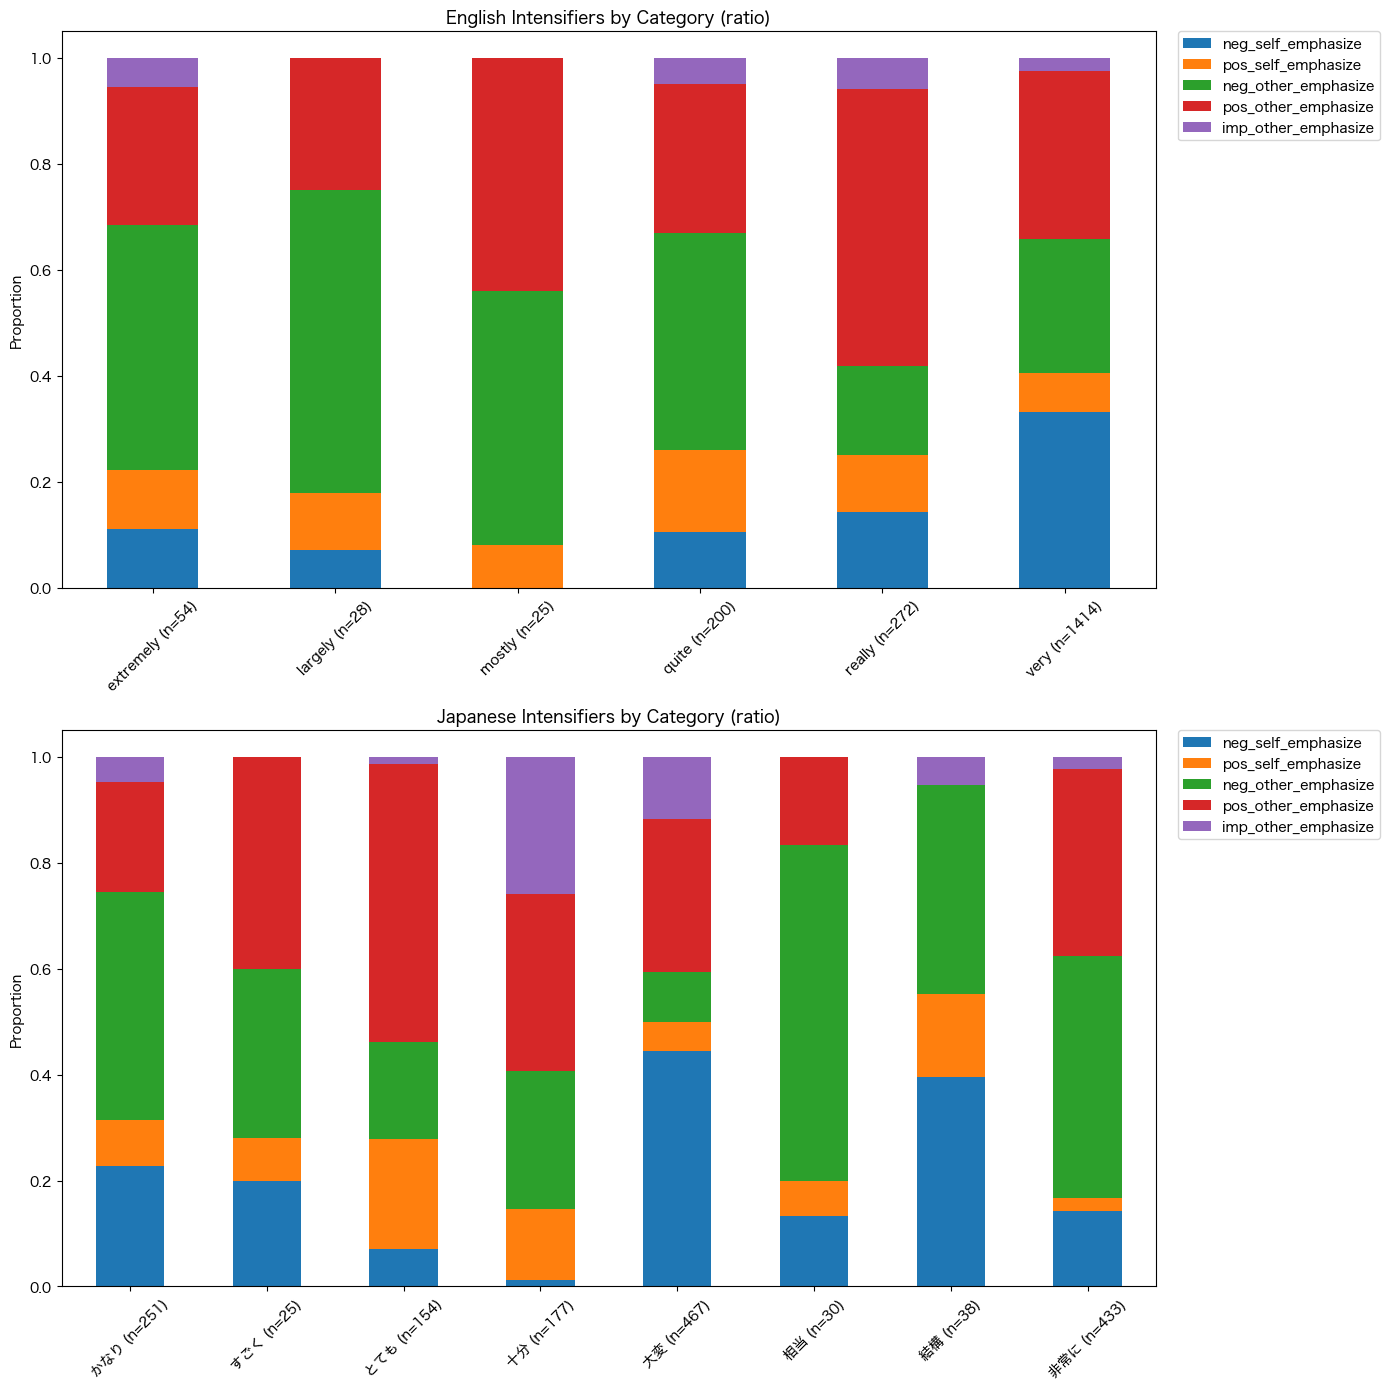

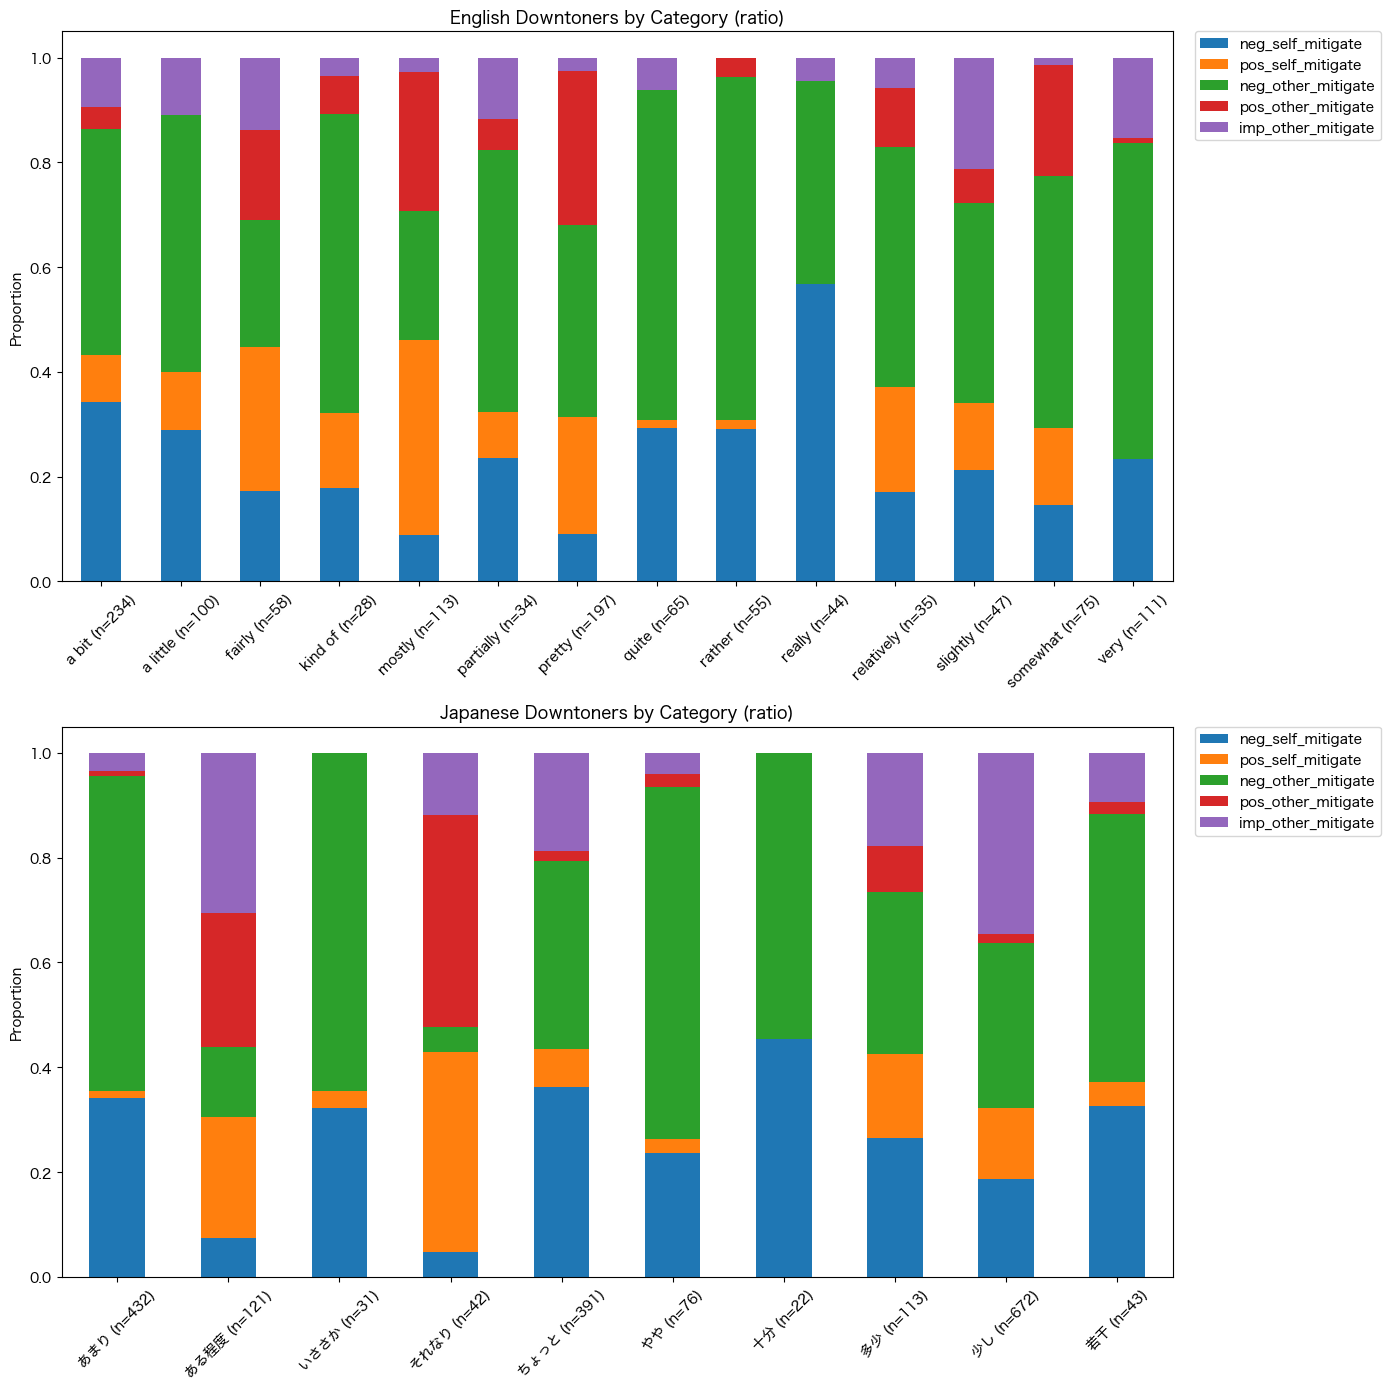

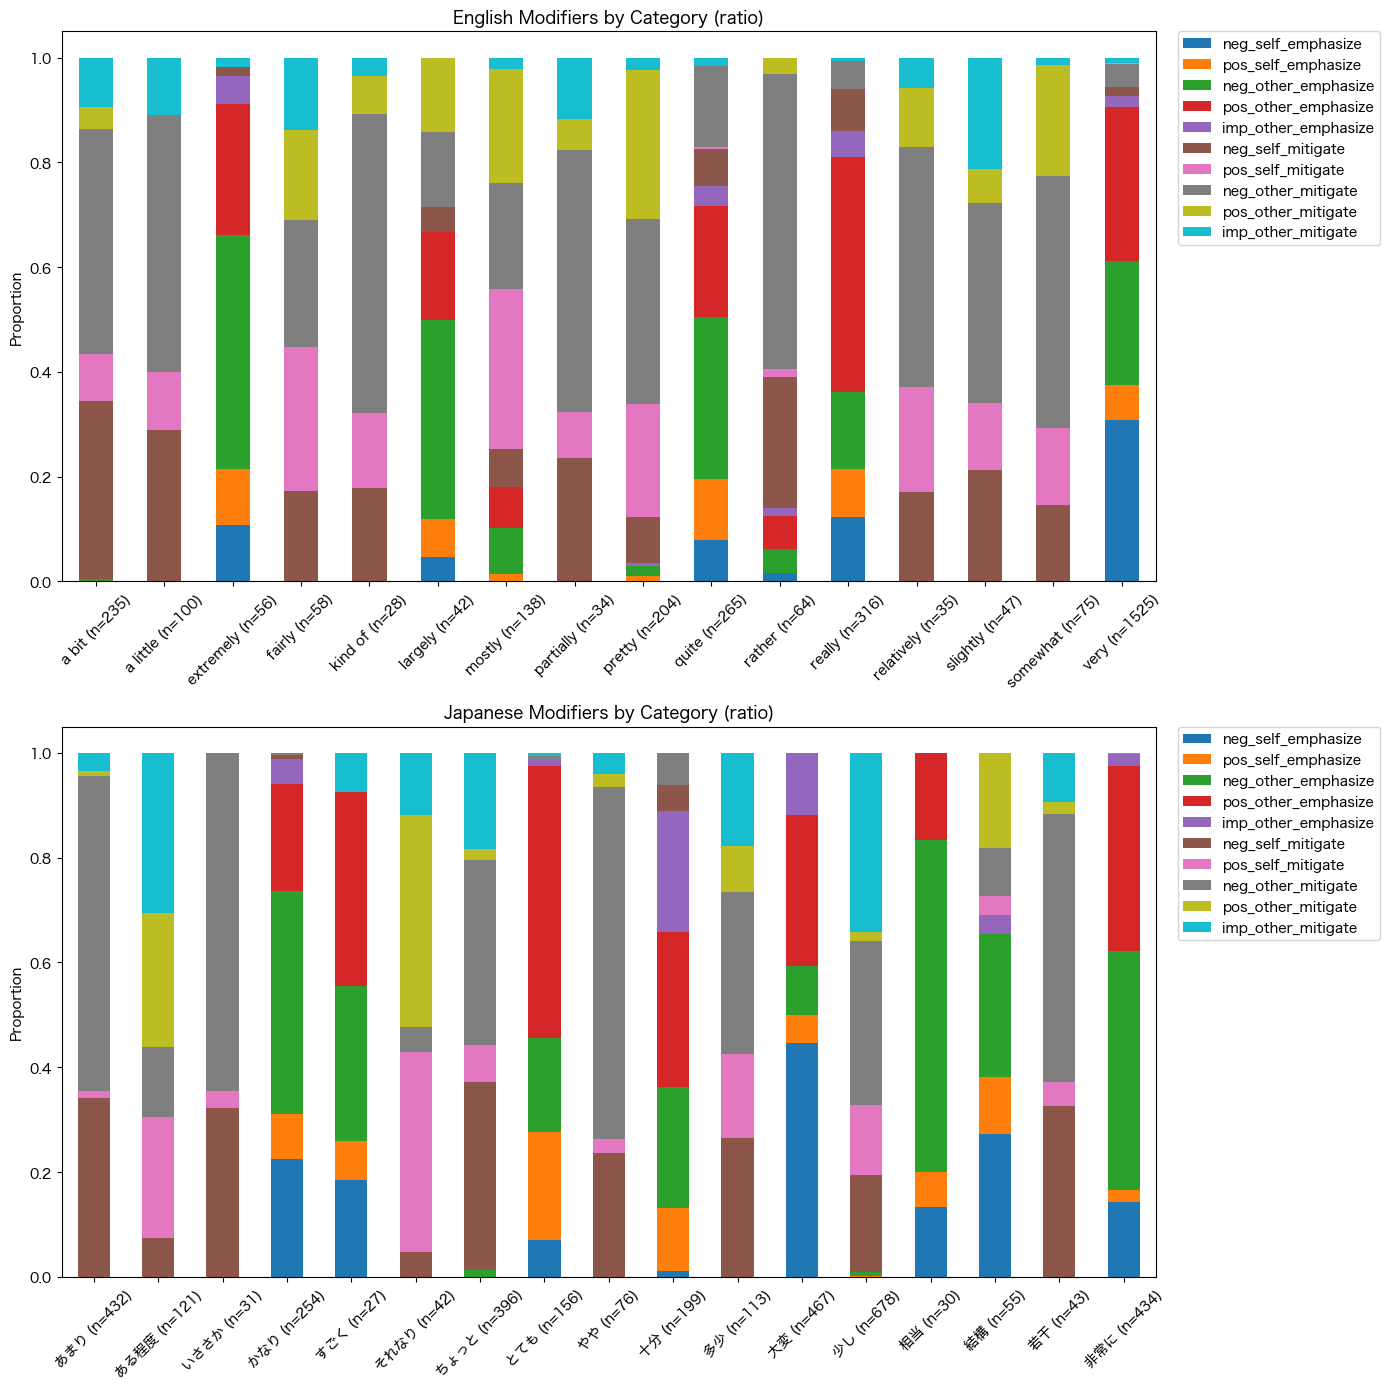

In [184]:
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Hiragino Sans'

intensifier_cats = ['neg_self_emphasize', 'pos_self_emphasize', 'neg_other_emphasize',
                     'pos_other_emphasize', 'imp_other_emphasize']
downtoner_cats = ['neg_self_mitigate', 'pos_self_mitigate', 'neg_other_mitigate',
                   'pos_other_mitigate', 'imp_other_mitigate']

MIN_N = 20


def plot_group(df, cats, title, ax):
    subset = df[df['category'].isin(cats)]
    counts = subset.groupby(['hedge', 'category']).size().unstack(fill_value=0)
    counts = counts.reindex(columns=cats, fill_value=0)

    totals = counts.sum(axis=1)
    counts = counts[totals >= MIN_N]
    totals = totals[totals >= MIN_N]

    ratio = counts.div(totals, axis=0)
    ratio.index = [f"{word} (n={totals[word]})" for word in ratio.index]

    ratio.plot(kind='bar', stacked=True, ax=ax, title=title)
    ax.tick_params(axis='x', rotation=45)
    ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
    ax.set_ylabel('Proportion')


n_words = max(en_modifier_checked['hedge'].nunique(), jp_modifier_checked['hedge'].nunique())

# --- intensifiers ---
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(max(14, n_words * 0.6), 14))
plot_group(en_modifier_checked, intensifier_cats, 'English Intensifiers by Category (ratio)', axes[0])
plot_group(jp_modifier_checked, intensifier_cats, 'Japanese Intensifiers by Category (ratio)', axes[1])
plt.tight_layout()
plt.show()

# --- downtoners ---
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(max(14, n_words * 0.6), 14))
plot_group(en_modifier_checked, downtoner_cats, 'English Downtoners by Category (ratio)', axes[0])
plot_group(jp_modifier_checked, downtoner_cats, 'Japanese Downtoners by Category (ratio)', axes[1])
plt.tight_layout()
plt.show()

# --- all ---
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(max(14, n_words * 0.6), 14))
plot_group(en_modifier_checked, intensifier_cats + downtoner_cats, 'English Modifiers by Category (ratio)', axes[0])
plot_group(jp_modifier_checked, intensifier_cats + downtoner_cats, 'Japanese Modifiers by Category (ratio)', axes[1])
plt.tight_layout()
plt.show()

In [139]:
# print all types of hedges in the dataset
print("English hedges:", en_modifier_checked['hedge'].unique())
print("Japanese hedges:", jp_modifier_checked['hedge'].unique())

English hedges: ['very' 'a little' 'really' 'rather' 'a bit' 'quite' 'extremely'
 'slightly' 'pretty' 'mostly' 'relatively' 'partially' 'somewhat'
 'largely' 'fairly' 'moderately' 'kind of' 'sort of' 'reasonably'
 'quite a bit']
Japanese hedges: ['少し' 'あまり' '大変' 'ちょっと' 'かなり' '相当' '非常に' '多少' '十分' 'とても' 'それなり' 'ずいぶん'
 '結構' 'ある程度' 'やや' 'いささか' '若干' 'すごく' 'わりと' 'やたら' 'とっても' 'ちょっぴり']


### Different ways of comparing variation in modifiers

In [182]:
import numpy as np
import pandas as pd
from scipy.spatial.distance import jensenshannon
from itertools import combinations
jp_modifier_checked = pd.read_csv("/Users/yuka/Documents/Academics/Stanford/Research/crossCulturalPoliteness/comparingCulturesPolitenessLLM/finalized_pipeline/data/results/jp_hedged_sentences_category_checked.csv")
en_modifier_checked = pd.read_csv("/Users/yuka/Documents/Academics/Stanford/Research/crossCulturalPoliteness/comparingCulturesPolitenessLLM/finalized_pipeline/data/results/en_hedged_sentences_category_checked.csv")
# only keep hedges in [very, really, extremely, quite a bit]
# en_modifier_checked = en_modifier_checked[en_modifier_checked['hedge'].isin(['very', 'really', 'extremely', 'quite a bit','mostly','largely','reasonably','moderately','somewhat','fairly'])]
# only keep modifeirs in a little, rather, a bit, quite, slightly, pretty, mostly, relatively, partially, somewhat, largely, fairly, moderately, kind of, sort of, reasonably
# en_modifier_checked = en_modifier_checked[en_modifier_checked['hedge'].isin(['a little', 'rather', 'a bit', 'quite', 'slightly', 'pretty', 'relatively', 'partially', 'somewhat', 'largely', 'fairly', 'moderately', 'kind of', 'sort of', 'reasonably'])]
# keep only the most frequent 5
en_modifier_counts = en_modifier_checked.groupby(['hedge', 'category']).size().unstack(fill_value=0)
# only keep modifiers in 大変, かなり, 相当, 非常に, 十分, とても, ずいぶん, すごく, やたら, とっても
# jp_modifier_checked = jp_modifier_checked[jp_modifier_checked['hedge'].isin(['大変', 'かなり', '相当', '非常に', '十分', 'とても', 'ずいぶん', 'すごく', 'やたら', 'とっても'])]
# only keep modifiers in 少し, あまり, ちょっと, 多少, それなり, 結構, ある程度, やや, いささか, 若干, わりと, ちょっぴり
# jp_modifier_checked = jp_modifier_checked[jp_modifier_checked['hedge'].isin(['少し', 'あまり', 'ちょっと', '多少', 'それなり', '結構', 'ある程度', 'やや', 'いささか', '若干', 'わりと', 'ちょっぴり'])]
jp_modifier_counts = jp_modifier_checked.groupby(['hedge', 'category']).size().unstack(fill_value=0)

# get rid of rows with cateogory neutral or other, since they are not informative for the comparison
en_modifier_counts = en_modifier_counts.drop(columns=['neutral', 'unclear'], errors='ignore')
jp_modifier_counts = jp_modifier_counts.drop(columns=['neutral', 'unclear'], errors='ignore')
# en_modifier_checked = en_modifier_checked[en_modifier_checked['hedge'].isin(en_modifier_checked['hedge'].value_counts().nlargest(10).index)]
# jp_modifier_checked = jp_modifier_checked[jp_modifier_checked['hedge'].isin(jp_modifier_checked['hedge'].value_counts().nlargest(10).index)]

print(en_modifier_checked['hedge'].value_counts())
print(jp_modifier_checked['hedge'].value_counts())

en_modifier_ratio = en_modifier_counts.div(en_modifier_counts.sum(axis=1), axis=0)
jp_modifier_ratio = jp_modifier_counts.div(jp_modifier_counts.sum(axis=1), axis=0)

MIN_N = 10

def pairwise_jsd_weighted(ratio_df, count_df):
    totals = count_df.sum(axis=1)
    words = ratio_df.index.tolist()
    results = []
    for w1, w2 in combinations(words, 2):
        p, q = ratio_df.loc[w1].values, ratio_df.loc[w2].values
        print(p,q)
        jsd = jensenshannon(p, q, base=2)
        weight = totals[w1] * totals[w2]  # conservative: limited by the rarer word
        results.append((w1, w2, jsd, weight))
    return pd.DataFrame(results, columns=['word1', 'word2', 'jsd', 'weight'])

# filter to words with enough data before computing pairs
en_keep = en_modifier_counts[en_modifier_counts.sum(axis=1) >= MIN_N]
jp_keep = jp_modifier_counts[jp_modifier_counts.sum(axis=1) >= MIN_N]
en_ratio_keep = en_modifier_ratio.loc[en_keep.index]
jp_ratio_keep = jp_modifier_ratio.loc[jp_keep.index]

en_jsd = pairwise_jsd_weighted(en_ratio_keep, en_keep)
jp_jsd = pairwise_jsd_weighted(jp_ratio_keep, jp_keep)

en_weighted_mean = np.average(en_jsd['jsd'], weights=en_jsd['weight'])
jp_weighted_mean = np.average(jp_jsd['jsd'], weights=jp_jsd['weight'])
print("English weighted mean JSD:", en_weighted_mean)
print("Japanese weighted mean JSD:", jp_weighted_mean)


def bootstrap_weighted_mean_diff(jsd1, jsd2, n_iter=10000):
    p1 = jsd1['weight'].values / jsd1['weight'].sum()
    p2 = jsd2['weight'].values / jsd2['weight'].sum()
    diffs = np.empty(n_iter)
    for i in range(n_iter):
        s1 = np.random.choice(jsd1['jsd'].values, size=len(jsd1), replace=True, p=p1)
        s2 = np.random.choice(jsd2['jsd'].values, size=len(jsd2), replace=True, p=p2)
        diffs[i] = s1.mean() - s2.mean()
    ci = np.percentile(diffs, [2.5, 97.5])
    return diffs.mean(), ci

mean_diff, ci = bootstrap_weighted_mean_diff(en_jsd, jp_jsd)
print(f"EN - JP weighted mean JSD diff: {mean_diff:.4f}, 95% CI: {ci}")

hedge
very           1608
really          323
quite           277
a bit           242
pretty          228
mostly          165
a little        105
somewhat         81
rather           67
extremely        64
fairly           63
slightly         57
relatively       47
largely          44
partially        37
kind of          31
sort of          13
reasonably       10
quite a bit       8
moderately        1
Name: count, dtype: int64
hedge
少し       706
大変       471
非常に      462
あまり      443
ちょっと     402
かなり      280
十分       206
とても      158
ある程度     134
多少       114
やや        76
結構        61
若干        44
それなり      43
相当        31
いささか      31
すごく       27
ずいぶん      26
やたら        9
とっても       5
わりと        4
ちょっぴり      1
Name: count, dtype: int64
[0.         0.09361702 0.00425532 0.42978723 0.         0.34042553
 0.         0.04255319 0.         0.0893617  0.        ] [0.   0.11 0.   0.49 0.   0.29 0.   0.   0.   0.11 0.  ]
[0.         0.09361702 0.00425532 0.42978723 0.         0.34042553
 0

In [172]:
import numpy as np
import pandas as pd
from scipy.spatial.distance import jensenshannon
from scipy.stats import entropy, wasserstein_distance
from itertools import combinations

EPS = 1e-10  # smoothing to avoid divide-by-zero / log(0) in KL and chi-squared

def pairwise_distances_weighted(ratio_df, count_df):
    totals = count_df.sum(axis=1)
    words = ratio_df.index.tolist()
    results = []
    for w1, w2 in combinations(words, 2):
        p = ratio_df.loc[w1].values.astype(float)
        q = ratio_df.loc[w2].values.astype(float)
        p_smooth = p + EPS
        q_smooth = q + EPS
        p_smooth /= p_smooth.sum()
        q_smooth /= q_smooth.sum()

        jsd = jensenshannon(p, q, base=2)
        kl_pq = entropy(p_smooth, q_smooth, base=2)          # KL(p || q)
        kl_qp = entropy(q_smooth, p_smooth, base=2)          # KL(q || p), since KL is asymmetric
        tvd = 0.5 * np.abs(p - q).sum()                      # total variation distance
        hellinger = np.sqrt(0.5 * np.sum((np.sqrt(p) - np.sqrt(q)) ** 2))
        chi_sq = np.sum((p_smooth - q_smooth) ** 2 / (p_smooth + q_smooth))
        wasserstein = wasserstein_distance(range(len(p)), range(len(q)), p, q)  # treats category order as-is
        cosine_dist = 1 - np.dot(p, q) / (np.linalg.norm(p) * np.linalg.norm(q) + EPS)

        weight = totals[w1] * totals[w2]

        results.append((w1, w2, jsd, kl_pq, kl_qp, tvd, hellinger, chi_sq, wasserstein, cosine_dist, weight))

    return pd.DataFrame(results, columns=[
        'word1', 'word2', 'jsd', 'kl_pq', 'kl_qp', 'tvd', 'hellinger',
        'chi_sq', 'wasserstein', 'cosine_dist', 'weight'
    ])

# filter to words with enough data before computing pairs
en_keep = en_modifier_counts[en_modifier_counts.sum(axis=1) >= MIN_N]
jp_keep = jp_modifier_counts[jp_modifier_counts.sum(axis=1) >= MIN_N]
en_ratio_keep = en_modifier_ratio.loc[en_keep.index]
jp_ratio_keep = jp_modifier_ratio.loc[jp_keep.index]

en_dist = pairwise_distances_weighted(en_ratio_keep, en_keep)
jp_dist = pairwise_distances_weighted(jp_ratio_keep, jp_keep)

metrics = ['jsd', 'kl_pq', 'kl_qp', 'tvd', 'hellinger', 'chi_sq', 'wasserstein', 'cosine_dist']

for m in metrics:
    en_wm = np.average(en_dist[m], weights=en_dist['weight'])
    jp_wm = np.average(jp_dist[m], weights=jp_dist['weight'])
    print(f"{m:12s}  EN={en_wm:.4f}  JP={jp_wm:.4f}")


def bootstrap_weighted_mean_diff(df1, df2, metric, n_iter=10000):
    p1 = df1['weight'].values / df1['weight'].sum()
    p2 = df2['weight'].values / df2['weight'].sum()
    diffs = np.empty(n_iter)
    for i in range(n_iter):
        s1 = np.random.choice(df1[metric].values, size=len(df1), replace=True, p=p1)
        s2 = np.random.choice(df2[metric].values, size=len(df2), replace=True, p=p2)
        diffs[i] = s1.mean() - s2.mean()
    ci = np.percentile(diffs, [2.5, 97.5])
    return diffs.mean(), ci


for m in metrics:
    mean_diff, ci = bootstrap_weighted_mean_diff(en_dist, jp_dist, m)
    sig = "significant" if ci[0] > 0 or ci[1] < 0 else "not significant"
    print(f"{m:12s}  EN-JP diff={mean_diff:.4f}  95% CI=[{ci[0]:.4f}, {ci[1]:.4f}]  ({sig})")

jsd           EN=0.6263  JP=0.7087
kl_pq         EN=5.8089  JP=13.8066
kl_qp         EN=12.0005  JP=14.4193
tvd           EN=0.6267  JP=0.7040
hellinger     EN=0.5863  JP=0.6776
chi_sq        EN=1.0090  JP=1.2398
wasserstein   EN=1.0407  JP=1.2174
cosine_dist   EN=0.5617  JP=0.6463
jsd           EN-JP diff=-0.0823  95% CI=[-0.1497, -0.0167]  (significant)
kl_pq         EN-JP diff=-7.9726  95% CI=[-10.1867, -5.7500]  (significant)
kl_qp         EN-JP diff=-2.4268  95% CI=[-5.1712, 0.3260]  (not significant)
tvd           EN-JP diff=-0.0773  95% CI=[-0.1473, -0.0080]  (significant)
hellinger     EN-JP diff=-0.0913  95% CI=[-0.1599, -0.0232]  (significant)
chi_sq        EN-JP diff=-0.2291  95% CI=[-0.3970, -0.0633]  (significant)
wasserstein   EN-JP diff=-0.1762  95% CI=[-0.2827, -0.0743]  (significant)
cosine_dist   EN-JP diff=-0.0844  95% CI=[-0.1670, -0.0017]  (significant)


### save to file

## Add judgements of dimensions of context
### Valence

### Check the following for each:
- (0) check if it is used as a modifier
- (1) if it is a question 
- (2) need for softening 
- (3) formality 
- (4) bearing on degree 
- (5) valence


In [ ]:

en_string_extracted = pd.read_csv('/Users/yuka/Documents/Academics/Stanford/Research/crossCulturalPoliteness/comparingCulturesPolitenessLLM/finalized_pipeline/data/results/en_hedged_gemini_labeled_sentences_checked.csv')
inline_requests = []
for row in en_string_extracted.itertuples():
    if en_string_extracted["is_modifier"][row.Index] == True:
        hedge = row.hedge
        sentence = row.sentence
        inline_requests.append(create_inline_requests([("{modifier}", hedge), ("{sentence}", sentence)], en_valence_prompt))

create_batch_job(inline_requests, display_name="en-hedge-category-classification")
# print(len(inline_requests))
    

BatchJob(
  create_time=datetime.datetime(2026, 7, 11, 21, 10, 42, 975459, tzinfo=TzInfo(UTC)),
  display_name='en-hedge-valence-classification',
  model='models/gemini-3-flash-preview',
  name='batches/ztzlyefx6p5xxqe3ft4a081af4upb79yrrnm',
  state=<JobState.JOB_STATE_PENDING: 'JOB_STATE_PENDING'>,
  update_time=datetime.datetime(2026, 7, 11, 21, 10, 42, 975459, tzinfo=TzInfo(UTC))
)

In [58]:
# open july9 csv
jp_string_extracted = pd.read_csv('/Users/yuka/Documents/Academics/Stanford/Research/crossCulturalPoliteness/comparingCulturesPolitenessLLM/finalized_pipeline/data/results/jp_hedged_sentencesJuly9_modifier_checked.csv')
jp_string_extracted["category"] = None
for index, row in jp_string_extracted.iterrows():
    print(index,row)
    break

0 hedge                                                         やや
sentence       僕が（投稿者本人以外が）移動をすると、要約欄への書き込みなどいろいろややこしい部分があるので...
is_modifier                                                False
modifies                                                     NaN
category                                                    None
Name: 0, dtype: object


In [ ]:
jp_string_extracted["category"] = None
batch = client.batches.get(name=batch_job.name)  # 完了後に取得し直す
file_content = client.files.download(file=batch.dest.file_name).decode("utf-8")
output_file = file_content.splitlines()
for row in output_file:
    index, relevant_output = get_index_output(row, key="category")
    jp_string_extracted.at[index, "category"] = relevant_output

NameError: name 'MODIFIER_CHECK_EXPLANATIONS' is not defined

## Generate frequency plots for each dimension

In [45]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

DEFAULT_DIMENSIONS = ["softener", "formality", "degree", "valence"]


def plot_average_by_modifier(
    results_df: pd.DataFrame,
    dimensions=None,
    title: str = "Average dimension ratings by modifier",
    figsize=(12, 6),
):
    """
    results_df: the dataframe produced by process_dataframe (must contain a
        'hedge' column plus numeric columns for each dimension).
    dimensions: which numeric columns to plot as grouped bars. Defaults to
        softener/formality/degree/valence ('is_question' is categorical
        Yes/No, so it's excluded by default).
    """
    if dimensions is None:
        dimensions = [d for d in DEFAULT_DIMENSIONS if d in results_df.columns]

    # Average each dimension per hedge, preserving a stable modifier order.
    means = results_df.groupby("hedge", sort=False)[dimensions].mean()

    modifiers = means.index.tolist()
    n_modifiers = len(modifiers)
    n_dims = len(dimensions)

    x = np.arange(n_modifiers)
    bar_width = 0.8 / n_dims  # keep the group of bars within one x-slot

    fig, ax = plt.subplots(figsize=figsize)
    colors = plt.cm.tab10(np.linspace(0, 1, n_dims))

    for i, dim in enumerate(dimensions):
        offset = (i - (n_dims - 1) / 2) * bar_width
        ax.bar(x + offset, means[dim].values, width=bar_width, label=dim, color=colors[i])

    ax.set_xticks(x)
    ax.set_xticklabels(modifiers, rotation=45, ha="right")
    ax.set_xlabel("Modifier")
    ax.set_ylabel("Average rating")
    ax.set_title(title)
    ax.legend(title="Dimension")
    fig.tight_layout()

    return fig, ax